## Семинар 8.2: различные имплементации градиентного бустинга

* XGboost + подбор гиперпараметров
* CatBoost + SHAP
* LightGBM

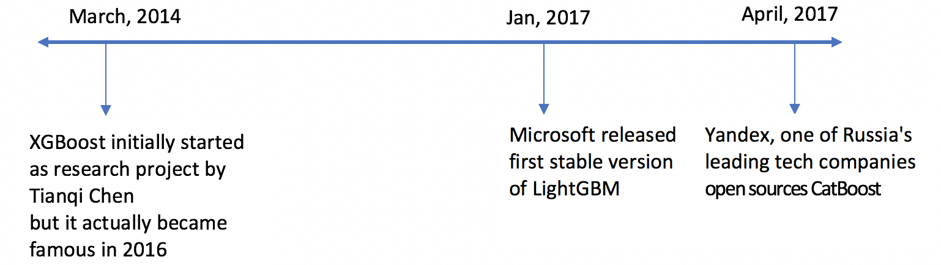

## 1. XGboost + подбор гиперпараметров

Код по xgboost основан на статье https://www.analyticsvidhya.com/blog/2016/03/complete-guide-parameter-tuning-xgboost-with-codes-python/

Основные особенности xgboost:
* базовый алгоритм приближает направление, посчитанное с учетом второй производной функции потерь

* функционал регуляризуется – добавляются штрафы за количество листьев и за норму коэффициентов

* Работаем с бакетами данных, а не с данными

* при построении дерева используется критерий информативности, зависящий от оптимального вектора сдвига

* критерий останова при обучении дерева также зависит от оптимального сдвига

Почитать подробнее тут: https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/lecture-notes/lecture10-ensembles.pdf

In [1]:
import os

import numpy as np
import pandas as pd
import xgboost as xgb
from matplotlib import pyplot as plt
from xgboost.sklearn import XGBClassifier

%matplotlib inline

Будем решать задачу классификации: по различным характеристикам клиента попытаемся определить, выплатит клиент долг или нет.

In [2]:
X_train = pd.read_csv("train_small.csv")
X_test = pd.read_csv("test_small.csv")
len(X_train), len(X_test)

(24365, 10443)

In [3]:
X_train.head()

,Existing_EMI,Loan_Amount_Applied,Loan_Tenure_Applied,Monthly_Income,Var4,Var5,Age,EMI_Loan_Submitted_Missing,Interest_Rate_Missing,Loan_Amount_Submitted_Missing,...,Var2_4,Var2_5,Var2_6,Mobile_Verified_0,Mobile_Verified_1,Source_0,Source_1,Source_2,Disbursed,ID
0,0.0,250000.0,5.0,23200,2,3,28,1,1,0,...,0,0,0,0,1,0,1,0,0.0,8161
1,0.0,0.0,0.0,25000,0,0,33,1,1,1,...,0,0,1,0,1,1,0,0,0.0,77530
2,0.0,0.0,0.0,95000,3,7,39,1,1,0,...,0,0,1,0,1,1,0,0,0.0,80633
3,0.0,0.0,0.0,29880,5,3,28,0,0,0,...,0,0,0,0,1,0,1,0,0.0,45059
4,4500.0,100000.0,3.0,30000,5,10,26,0,0,0,...,0,0,1,0,1,1,0,0,0.0,54857


Для того, чтобы бустинг показал хорошее качество и не переобучился, необходимо аккуратно подобрать его гиперпараметры. 

Алгоритм подбора гиперпараметров следующий:

* Выбираем относительно большую learning_rate ($ \eta \in [0.05, 0.3]$), подбираем оптимальное число деревьев для выбранного $ \eta $

* Настраиваем параметры деревьев, начиная с самых значимых (max_depth, min_child_weight, gamma, subsample, colsample_bytree)

* Настраиваем регуляризации ($ \lambda, \alpha $)

* Уменьшаем learning_rate, пропорционально увеличиваем число деревьев


Целевая функция XGBoost выглядит так:

$\text{XGBoost Objective} = Loss + \Omega(дерево)$

Где $\Omega(дерево)$ — это штраф за сложность дерева.

Из чего состоит этот штраф $\Omega$?

$\Omega(дерево) = \gamma \cdot T + \frac{1}{2} \cdot \lambda \cdot \sum w^2 + \alpha \cdot \sum |w|$

Где:
- T — количество листьев в дереве (чем больше листьев, тем сложнее дерево)
- w — значения в листьях (вес прогноза)
- $\gamma$ (gamma) — штраф за добавление нового листа
- $\lambda$ (lambda) — L2-регуляризация (штрафует большие значения w)
- $\alpha$ (alpha) — L1-регуляризация (тоже штрафует большие значения w, но по-другому)

In [4]:
xgb1 = XGBClassifier(
    learning_rate=0.1, n_estimators=150, objective="binary:logistic", nthread=4, scale_pos_weight=1, seed=27
)

In [5]:
target = "Disbursed"
IDcol = "ID"

In [6]:
X_train["Disbursed"].value_counts(), len(X_train)

(Disbursed
 0.0    23999
 1.0      366
 Name: count, dtype: int64,
 24365)

Создадим функцию для моделирования и кросс-валидации

Эта функция делает следующее:
1. обучает модель
2. вычисляет accuracy на тренировочной выборке
3. вычисляет AUC на тренировочной выборке
4. вычисляет AUC на тестовой выборке
5. обновляет n_estimators с помощью встроенной в пакет xgboost функции cv
6. строит диаграмму Feature Importance 



In [7]:
from sklearn import metrics


def modelfit(alg, dtrain, dtest, predictors, use_train_cv=True, cv_folds=5, early_stopping_rounds=50):

    if use_train_cv:
        xgb_param = alg.get_xgb_params()
        xgtrain = xgb.DMatrix(dtrain[predictors].values, label=dtrain[target].values)
        xgtest = xgb.DMatrix(dtest[predictors].values)
        cvresult = xgb.cv(
            xgb_param,
            xgtrain,
            num_boost_round=alg.get_params()["n_estimators"],
            nfold=cv_folds,
            metrics="auc",
            early_stopping_rounds=early_stopping_rounds,
        )
        alg.set_params(n_estimators=cvresult.shape[0])

    # Fit the algorithm on the data
    alg.fit(dtrain[predictors], dtrain["Disbursed"])

    # Predict training set:
    dtrain_predictions = alg.predict(dtrain[predictors])
    dtrain_predprob = alg.predict_proba(dtrain[predictors])[:, 1]

    # Print model report:
    print("\nModel Report")
    print("Accuracy : %.4g" % metrics.accuracy_score(dtrain["Disbursed"].values, dtrain_predictions))
    print("AUC Score (Train): %f" % metrics.roc_auc_score(dtrain["Disbursed"], dtrain_predprob))

    # Predict on testing data:
    dtest["predprob"] = alg.predict_proba(dtest[predictors])[:, 1]
    print("AUC Score (Test): %f" % metrics.roc_auc_score(dtest["Disbursed"], dtest["predprob"]))

    feat_imp = pd.Series(alg.get_booster().get_fscore()).sort_values(ascending=False)
    feat_imp.plot(kind="bar", title="Feature Importances")
    plt.ylabel("Feature Importance Score")

Начинаем последовательный подбор параметров при большом learning_rate


Model Report
Accuracy : 0.985
AUC Score (Train): 0.914990
AUC Score (Test): 0.826214


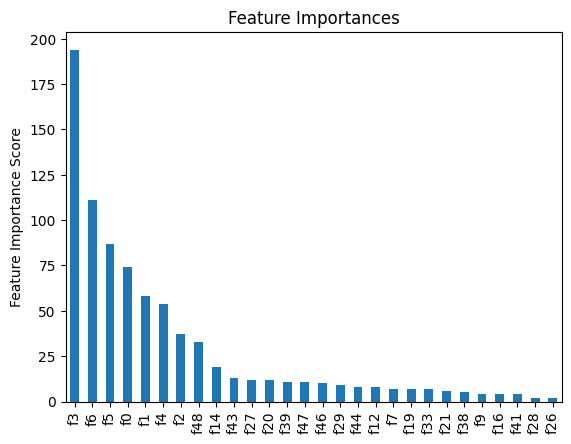

In [8]:
predictors = [x for x in X_train.columns if x not in [target, IDcol]]
xgb1 = XGBClassifier(
    learning_rate=0.1,
    n_estimators=150,
    objective="binary:logistic",
    nthread=4,
    scale_pos_weight=1,
    seed=27,
    eval_metric="auc",
)
modelfit(xgb1, X_train, X_test, predictors)

Перебираем max_depth и min_child_weight по сетке.

In [9]:
from sklearn.model_selection import GridSearchCV

param_test1 = {"max_depth": range(3, 10, 2), "min_child_weight": range(1, 6, 2)}
gsearch1 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=150,
        objective="binary:logistic",
        nthread=4,
        scale_pos_weight=1,
        seed=27,
        eval_metric="auc",
    ),
    param_grid=param_test1,
    scoring="roc_auc",
    n_jobs=4,
    cv=5,
)
gsearch1.fit(X_train[predictors], X_train[target])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...thread=4, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(3, 10, 2), 'min_child_weight': range(1, 6, 2)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also di

In [10]:
gsearch1.best_params_, gsearch1.best_score_

({'max_depth': 3, 'min_child_weight': 5}, np.float64(0.8264881395655903))

Уточняем предсказание

In [11]:
param_test2 = {"max_depth": [2, 3, 4], "min_child_weight": [2, 3, 4]}
gsearch2 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=150,
        objective="binary:logistic",
        nthread=4,
        scale_pos_weight=1,
        seed=27,
        eval_metric="auc",
    ),
    param_grid=param_test2,
    scoring="roc_auc",
    n_jobs=4,
    cv=5,
)
gsearch2.fit(X_train[predictors], X_train[target])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...thread=4, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_child_weight': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed

In [12]:
gsearch2.best_params_, gsearch2.best_score_

({'max_depth': 3, 'min_child_weight': 4}, np.float64(0.8274114000090442))

Зафиксируем найденный max_depth и подберем min_child_weight

In [13]:
param_test2b = {"min_child_weight": [5, 6, 7]}
gsearch2b = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=150,
        max_depth=3,
        objective="binary:logistic",
        nthread=4,
        scale_pos_weight=1,
        seed=27,
        eval_metric="auc",
    ),
    param_grid=param_test2b,
    scoring="roc_auc",
    n_jobs=4,
    cv=5,
)
gsearch2b.fit(X_train[predictors], X_train[target])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...thread=4, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'min_child_weight': [5, 6, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [14]:
gsearch2b.best_params_, gsearch2b.best_score_

({'min_child_weight': 5}, np.float64(0.8264881395655903))

Мы подобрали max_depth и min_child_weight - дальше будем использовать подобранные значения параметров. Подберите по сетке параметр gamma на отрезке от 0 до 1.

In [15]:
param_test3 = {"gamma": np.linspace(0, 1, num=11)}
gsearch3b = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=150,
        max_depth=3,
        min_child_weight=5,
        objective="binary:logistic",
        nthread=4,
        scale_pos_weight=1,
        seed=27,
        eval_metric="auc",
    ),
    param_grid=param_test3,
    scoring="roc_auc",
    n_jobs=4,
    cv=5,
)
gsearch3b.fit(X_train[predictors], X_train[target])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...thread=4, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': array([0. , 0....8, 0.9, 1. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold a

In [16]:
gsearch3b.best_params_, gsearch3b.best_score_

({'gamma': np.float64(0.5)}, np.float64(0.8283620837550437))

Установите в качестве параметров алгоритма подобранные max_depth, min_child_weight и gamma и посмотрите как изменилось качество.


Model Report
Accuracy : 0.985
AUC Score (Train): 0.872650
AUC Score (Test): 0.830128


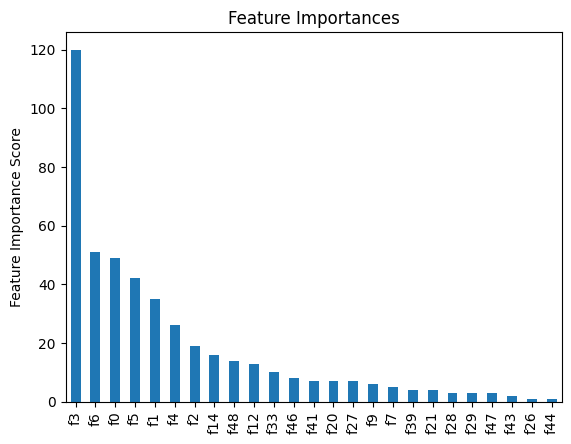

In [17]:
predictors = [x for x in X_train.columns if x not in [target, IDcol]]
xgb2 = XGBClassifier(
    learning_rate=0.1,
    n_estimators=150,
    max_depth=3,
    min_child_weight=5,
    gamma=0.4,
    objective="binary:logistic",
    nthread=4,
    scale_pos_weight=1,
    seed=27,
)
modelfit(xgb2, X_train, X_test, predictors)

Подберите по сетке параметры subsample и colsample_bytree. Используйте значения этих параметров: [0.6,0.7,0.8,0.9,1.]

In [18]:
param_test4 = {
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
}
gsearch4 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=150,
        max_depth=3,
        min_child_weight=5,
        gamma=0.4,
        objective="binary:logistic",
        nthread=8,
        scale_pos_weight=1,
        seed=27,
    ),
    param_grid=param_test4,
    scoring="roc_auc",
    n_jobs=8,
    cv=5,
)
gsearch4.fit(X_train[predictors], X_train[target])
gsearch4.best_params_, gsearch3b.best_score_

({'colsample_bytree': 0.9, 'subsample': 1.0}, np.float64(0.8283620837550437))

Подберите параметр регуляризации reg_alpha. Попробуйте [1e-5, 1e-2, 0.1, 1, 100]

In [19]:
param_test5 = {
    "reg_alpha": [1e-5, 1e-2, 0.1, 1, 100],
}
gsearch5 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=150,
        max_depth=3,
        min_child_weight=5,
        gamma=0.4,
        colsample_bytree=0.8,
        subsample=1.0,
        objective="binary:logistic",
        nthread=8,
        scale_pos_weight=1,
        seed=27,
    ),
    param_grid=param_test5,
    scoring="roc_auc",
    n_jobs=8,
    cv=5,
)
gsearch5.fit(X_train[predictors], X_train[target])
gsearch5.best_params_, gsearch3b.best_score_

({'reg_alpha': 0.1}, np.float64(0.8283620837550437))

Запустите обучение и предсказание на найденных параметрах и посмотрите на качество.


Model Report
Accuracy : 0.985
AUC Score (Train): 0.878090
AUC Score (Test): 0.830705


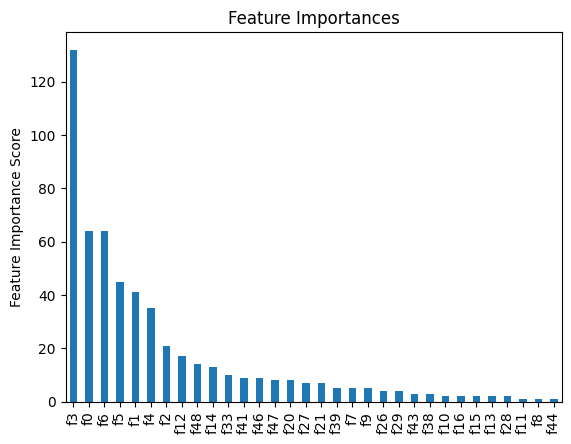

In [20]:
xgb3 = XGBClassifier(
    learning_rate=0.1,
    n_estimators=150,
    max_depth=3,
    min_child_weight=5,
    gamma=0.4,
    subsample=1.0,
    colsample_bytree=0.8,
    reg_alpha=0.01,
    objective="binary:logistic",
    nthread=4,
    scale_pos_weight=1,
    seed=27,
)
modelfit(xgb3, X_train, X_test, predictors)

Уменьшите learning_rate до 0.01 и пропорционально увеличьте число деревьев. Все подобранные параметры остаются такими же. Обучите модель и сделайте предсказание. Посмотрите на качество.


Model Report
Accuracy : 0.985
AUC Score (Train): 0.868230
AUC Score (Test): 0.830562


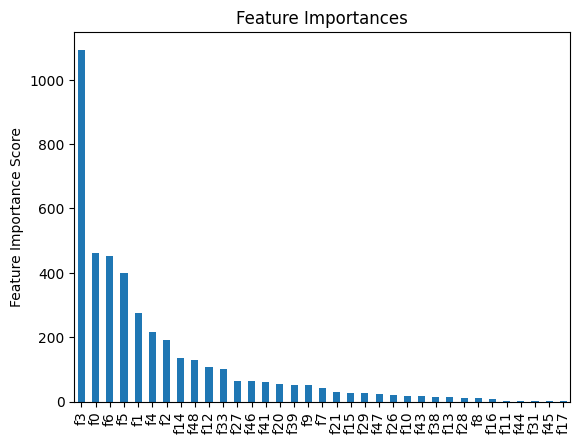

In [21]:
# Your code here
xgb3 = XGBClassifier(
    learning_rate=0.01,
    n_estimators=1500,
    max_depth=3,
    min_child_weight=5,
    gamma=0.4,
    subsample=1.0,
    colsample_bytree=0.8,
    reg_alpha=0.01,
    objective="binary:logistic",
    nthread=4,
    scale_pos_weight=1,
    seed=27,
)
modelfit(xgb3, X_train, X_test, predictors)

## 2. CatBoost

Оригинальный ноутбук здесь: https://github.com/catboost/tutorials/blob/master/classification/classification_tutorial.ipynb

Особенности катбуста:

* используются симметричные деревья решений

* для кодирования категориальных признаков используется большой набор методов

* динамический бустинг (ordered)

Благодаря использованию симметричных деревьев и динамическому бустингу катбуст гораздо более устойчив к переобучению, чем другие имплементации градиентного бустинга. Поэтому он показывает хорошее качество даже при дефолтных параметрах.

Посмотреть видео про катбуст: https://yandex.ru/video/preview/?filmId=10919886479285152550&from=tabbar&text=catboost+анна+вероника

Устанавливаем библиотеки

In [22]:
# !pip install --upgrade catboost
# !pip install shap
# !pip install 'numpy==1.26.4'
# !pip install --upgrade ipywidgets
# !jupyter nbextension enable --py widgetsnbextension

import catboost

In [23]:
from matplotlib import pyplot as plt

%matplotlib inline

In [24]:
np.set_printoptions(precision=4)
import catboost
from catboost import *
from catboost import datasets

Считываем данные. Данные содержат только категориальные признаки, причем с большим количеством категорий. Признаки - закодированные характеристики сотрудника и некоторого ресурса, целевая переменная - есть ли у сотрудника доступ к ресурсу.

In [25]:
(train_df, test_df) = catboost.datasets.amazon()

In [26]:
train_df.head()

,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


Готовим данные

In [27]:
y = train_df.ACTION
X = train_df.drop("ACTION", axis=1)

Создаем список категориальных фичей

In [28]:
cat_features = list(range(0, X.shape[1]))
print(cat_features)

[0, 1, 2, 3, 4, 5, 6, 7, 8]


Смотрим на соотношение классов

In [29]:
print("Labels: {}".format(set(y)))
print("Zero count = {}, One count = {}".format(len(y) - sum(y), sum(y)))

Labels: {0, 1}
Zero count = 1897, One count = 30872


Способы создать Pool - объект, содержащий матрицу объект-признак X, вектор ответов, список номеров колонок с категориальными признаками.

In [30]:
pool1 = Pool(data=X, label=y, cat_features=cat_features)

pool2 = Pool(data=X, cat_features=cat_features)

# Fastest way to create a Pool is to create it from numpy matrix.
# This way should be used if you want fast predictions
# or fastest way to load the data in python.

X_prepared = X.values.astype(str).astype(object)
# For FeaturesData class categorial features must have type str

pool3 = Pool(data=FeaturesData(cat_feature_data=X_prepared, cat_feature_names=list(X)), label=y.values)

print("Dataset shape")
print("dataset 1:" + str(pool1.shape) + "\ndataset 2:" + str(pool2.shape) + "\ndataset 3: " + str(pool3.shape))

print("\n")
print("Column names")
print("dataset 1:")
print(pool1.get_feature_names())
print("\ndataset 2:")
print(pool2.get_feature_names())
print("\ndataset 3:")
print(pool3.get_feature_names())

Dataset shape
dataset 1:(32769, 9)
dataset 2:(32769, 9)
dataset 3: (32769, 9)


Column names
dataset 1:
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']

dataset 2:
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']

dataset 3:
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']


Разбиваем данные на train и validation

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_validation, y_train, y_validation = train_test_split(X, y, train_size=0.8, random_state=42)

Выбираем функцию потерь

Для бинарной классификации можем использовать:

* `Logloss`

* `CrossEntropy`

In [32]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(iterations=5, learning_rate=0.1, loss_function="CrossEntropy")
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_validation, y_validation), verbose=False)
print("Model is fitted: " + str(model.is_fitted()))
print("Model params:")
print(model.get_params())

Model is fitted: True
Model params:
{'iterations': 5, 'learning_rate': 0.1, 'loss_function': 'CrossEntropy'}


Печать результатов

In [33]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=15,
    # verbose=5,
)
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
)

Learning rate set to 0.441257
0:	learn: 0.4227692	test: 0.4210990	best: 0.4210990 (0)	total: 4.45ms	remaining: 62.3ms
1:	learn: 0.3156595	test: 0.3124516	best: 0.3124516 (1)	total: 11.2ms	remaining: 72.5ms
2:	learn: 0.2629962	test: 0.2592571	best: 0.2592571 (2)	total: 14.2ms	remaining: 56.9ms
3:	learn: 0.2318854	test: 0.2270579	best: 0.2270579 (3)	total: 20.9ms	remaining: 57.4ms
4:	learn: 0.2074867	test: 0.2005202	best: 0.2005202 (4)	total: 27.7ms	remaining: 55.4ms
5:	learn: 0.1958334	test: 0.1865581	best: 0.1865581 (5)	total: 30.9ms	remaining: 46.4ms
6:	learn: 0.1886256	test: 0.1773071	best: 0.1773071 (6)	total: 35.9ms	remaining: 41ms
7:	learn: 0.1835420	test: 0.1709810	best: 0.1709810 (7)	total: 42.7ms	remaining: 37.4ms
8:	learn: 0.1821405	test: 0.1688308	best: 0.1688308 (8)	total: 47.7ms	remaining: 31.8ms
9:	learn: 0.1785695	test: 0.1645358	best: 0.1645358 (9)	total: 51.6ms	remaining: 25.8ms
10:	learn: 0.1767659	test: 0.1625349	best: 0.1625349 (10)	total: 57.7ms	remaining: 21ms
11:	

Визуализация метрик

In [34]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(iterations=50, random_seed=63, learning_rate=0.5, custom_loss=["AUC", "Accuracy"])
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_validation, y_validation), verbose=False, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Сравнение моделей

In [35]:
model1 = CatBoostClassifier(learning_rate=0.7, iterations=100, random_seed=0, train_dir="learing_rate_0.7")

model2 = CatBoostClassifier(learning_rate=0.01, iterations=100, random_seed=0, train_dir="learing_rate_0.01")
model1.fit(X_train, y_train, eval_set=(X_validation, y_validation), cat_features=cat_features, verbose=False)
model2.fit(X_train, y_train, eval_set=(X_validation, y_validation), cat_features=cat_features, verbose=False)

In [36]:
from catboost import MetricVisualizer

MetricVisualizer(["learing_rate_0.01", "learing_rate_0.7"]).start()

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Оптимальное количество деревьев

In [37]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=100,
    random_seed=63,
    learning_rate=0.5,
    # use_best_model=False
)
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_validation, y_validation), verbose=False, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [38]:
print("Tree count: " + str(model.tree_count_))

Tree count: 92


Кросс-валидация

In [39]:
from catboost import cv

params = {}
params["loss_function"] = "Logloss"
params["iterations"] = 80
params["custom_loss"] = "AUC"
params["random_seed"] = 63
params["learning_rate"] = 0.5

cv_data = cv(
    params=params,
    pool=Pool(X, label=y, cat_features=cat_features),
    fold_count=5,
    shuffle=True,
    partition_random_seed=0,
    plot=True,
    stratified=False,
    verbose=False,
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]

bestTest = 0.1674879003
bestIteration = 36

Training on fold [1/5]

bestTest = 0.164632916
bestIteration = 48

Training on fold [2/5]

bestTest = 0.1540626982
bestIteration = 64

Training on fold [3/5]

bestTest = 0.1426916182
bestIteration = 78

Training on fold [4/5]

bestTest = 0.1560519524
bestIteration = 55



In [40]:
cv_data.head()

,iterations,test-Logloss-mean,test-Logloss-std,train-Logloss-mean,train-Logloss-std,test-AUC-mean,test-AUC-std
0,0,0.302367,0.004317,0.302196,0.004517,0.513577,0.030360
1,1,0.226879,0.007618,0.228406,0.005219,0.640026,0.046937
2,2,0.189560,0.005706,0.195723,0.004473,0.797855,0.011978
3,3,0.178061,0.006784,0.186107,0.003632,0.815144,0.010133
4,4,0.171654,0.007401,0.181249,0.002254,0.827182,0.004918


In [41]:
best_value = np.min(cv_data["test-Logloss-mean"])
best_iter = np.argmin(cv_data["test-Logloss-mean"])

print(
    "Best validation Logloss score, not stratified: {:.4f}±{:.4f} on step {}".format(
        best_value, cv_data["test-Logloss-std"][best_iter], best_iter
    )
)

Best validation Logloss score, not stratified: 0.1579±0.0098 on step 64


Детектор переобучения

In [42]:
model_with_early_stop = CatBoostClassifier(iterations=200, random_seed=63, learning_rate=0.5, early_stopping_rounds=20)
model_with_early_stop.fit(
    X_train, y_train, cat_features=cat_features, eval_set=(X_validation, y_validation), verbose=False, plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [43]:
print(model_with_early_stop.tree_count_)

21


In [44]:
model_with_early_stop = CatBoostClassifier(
    eval_metric="AUC", iterations=200, random_seed=63, learning_rate=0.5, early_stopping_rounds=20
)
model_with_early_stop.fit(
    X_train, y_train, cat_features=cat_features, eval_set=(X_validation, y_validation), verbose=False, plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [45]:
print(model_with_early_stop.tree_count_)

52


Вычисление метрик качества и выбор порога принятия решения

In [46]:
model = CatBoostClassifier(
    random_seed=63,
    iterations=200,
    learning_rate=0.03,
)
model.fit(X_train, y_train, cat_features=cat_features, verbose=False, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Получение предсказаний

In [47]:
model.tree_count_

200

In [48]:
print(model.predict_proba(X_validation))

[[0.0117 0.9883]
 [0.0185 0.9815]
 [0.0165 0.9835]
 ...
 [0.0136 0.9864]
 [0.0097 0.9903]
 [0.0159 0.9841]]


In [49]:
print(model.predict(X_validation))

[1 1 1 ... 1 1 1]


Последовательные предсказания

In [50]:
predictions_gen = model.staged_predict_proba(data=X_validation, ntree_start=0, ntree_end=5, eval_period=1)
try:
    for iteration, predictions in enumerate(predictions_gen):
        print("Iteration " + str(iteration) + ", predictions:")
        print(predictions)
except Exception:
    pass

Iteration 0, predictions:
[[0.4794 0.5206]
 [0.4794 0.5206]
 [0.4794 0.5206]
 ...
 [0.4794 0.5206]
 [0.4794 0.5206]
 [0.4794 0.5206]]
Iteration 1, predictions:
[[0.4588 0.5412]
 [0.4588 0.5412]
 [0.4588 0.5412]
 ...
 [0.4588 0.5412]
 [0.4588 0.5412]
 [0.4588 0.5412]]
Iteration 2, predictions:
[[0.4397 0.5603]
 [0.4397 0.5603]
 [0.4397 0.5603]
 ...
 [0.4397 0.5603]
 [0.4397 0.5603]
 [0.4397 0.5603]]
Iteration 3, predictions:
[[0.4184 0.5816]
 [0.4184 0.5816]
 [0.4259 0.5741]
 ...
 [0.4184 0.5816]
 [0.4184 0.5816]
 [0.4184 0.5816]]
Iteration 4, predictions:
[[0.4004 0.5996]
 [0.4004 0.5996]
 [0.4078 0.5922]
 ...
 [0.4004 0.5996]
 [0.4004 0.5996]
 [0.4004 0.5996]]


Важность признаков

In [51]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,RESOURCE,21.843902
1,MGR_ID,18.995991
2,ROLE_DEPTNAME,18.350103
3,ROLE_TITLE,8.867116
4,ROLE_FAMILY_DESC,7.393938
5,ROLE_ROLLUP_2,6.774388
6,ROLE_CODE,6.579637
7,ROLE_FAMILY,6.298606
8,ROLE_ROLLUP_1,4.896318


### Shap values 

Классические способы измерения важности признаков обладают существенным недостатком: непонятно, как именно каждый признак влияет на предсказание модели. Shap values (значения Шэпли) - способ измерения важности признаков, исправляющий этот недостаток.

Подробнее читайте тут: https://habr.com/ru/post/428213/

In [52]:
import shap

shap_values = model.get_feature_importance(pool1, type="ShapValues")

expected_value = shap_values[0, -1]
shap_values = shap_values[:, :-1]

print(shap_values.shape)

(32769, 9)


/tmp/ipykernel_103922/3017445420.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


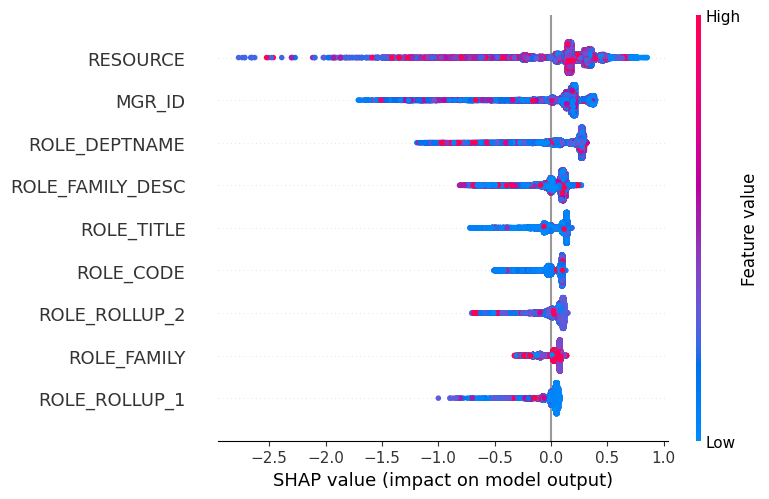

In [53]:
shap.summary_plot(shap_values, X)

Shap-values для конкретного объекта.

In [54]:
shap.initjs()
shap.force_plot(expected_value, shap_values[3, :], X.iloc[3, :])

Сохранение модели

In [55]:
my_best_model = CatBoostClassifier(iterations=10)
my_best_model.fit(X_train, y_train, eval_set=(X_validation, y_validation), cat_features=cat_features, verbose=False)
my_best_model.save_model("catboost_model.bin")
my_best_model.save_model("catboost_model.json", format="json")

In [56]:
my_best_model.load_model("catboost_model.bin")
print(my_best_model.get_params())
print(my_best_model.random_seed_)

{'iterations': 10, 'loss_function': 'Logloss', 'verbose': 0}
0


Подбор гиперпараметров

In [57]:
cat = CatBoostClassifier(n_estimators=50)

grid = {"learning_rate": [0.03, 0.1], "depth": [4, 6, 10]}
#        'l2_leaf_reg': [1, 3, 5, 7, 9]}

grid_search_result = cat.grid_search(grid, X=X_train, y=y_train, verbose=False, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6563263	test: 0.6566101	best: 0.6566101 (0)	total: 11.3ms	remaining: 555ms
1:	learn: 0.6232045	test: 0.6238316	best: 0.6238316 (1)	total: 14.4ms	remaining: 346ms
2:	learn: 0.5919160	test: 0.5929842	best: 0.5929842 (2)	total: 21.2ms	remaining: 332ms
3:	learn: 0.5631959	test: 0.5646021	best: 0.5646021 (3)	total: 26.3ms	remaining: 302ms
4:	learn: 0.5363332	test: 0.5381152	best: 0.5381152 (4)	total: 39.2ms	remaining: 353ms
5:	learn: 0.5120908	test: 0.5141432	best: 0.5141432 (5)	total: 50.7ms	remaining: 372ms
6:	learn: 0.4895722	test: 0.4918744	best: 0.4918744 (6)	total: 60.1ms	remaining: 369ms
7:	learn: 0.4687120	test: 0.4712743	best: 0.4712743 (7)	total: 62.9ms	remaining: 330ms
8:	learn: 0.4494477	test: 0.4523054	best: 0.4523054 (8)	total: 67.8ms	remaining: 309ms
9:	learn: 0.4316643	test: 0.4348133	best: 0.4348133 (9)	total: 70.6ms	remaining: 282ms
10:	learn: 0.4156638	test: 0.4190866	best: 0.4190866 (10)	total: 73.2ms	remaining: 260ms
11:	learn: 0.4008061	test: 0.4045471	best

In [58]:
grid_search_result["params"]

{'depth': 10, 'learning_rate': 0.1}

Хорошее описание гиперпараметров катбуста: https://habr.com/ru/company/otus/blog/527554/

## LightGBM

Особенности LightGBM:

* полиственное (leaf-wise), а не поуровневое (depth-wise) построение деревьев

* GOSS (отбор самых нужных объектов Gradient-based One-Side Sampling)

* быстрое построение дерева, позволяющее не кодировать категориальные признаки, а использовать исходные категории для получения предикатов

* Exclusive Feature Bundling (EFB) — Объединение признаков - ускорение построения деревьев за счёт бинаризации признаков (объединение значений признака в группы)

Почитать подробнее можно тут: https://medium.com/@pushkarmandot/https-medium-com-pushkarmandot-what-is-lightgbm-how-to-implement-it-how-to-fine-tune-the-parameters-60347819b7fc

In [59]:
# !pip install lightgbm

In [60]:
import lightgbm as lgb
import pandas as pd

# from sklearn.datasets import load_boston
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split

housing = fetch_california_housing()
X_full = housing["data"]
y_full = housing["target"]

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=100, random_state=241)

Обучение

In [61]:
print("Starting training...")
# train
gbm = lgb.LGBMRegressor(num_leaves=31, learning_rate=0.05, n_estimators=20)
gbm.fit(
    X_train, y_train, eval_set=[(X_test, y_test)], eval_metric="l1", callbacks=[lgb.early_stopping(stopping_rounds=5)]
)

Starting training...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 20540, number of used features: 8
[LightGBM] [Info] Start training from score 2.069264
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[20]	valid_0's l1: 0.507764	valid_0's l2: 0.430877


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,20
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Предсказание и оценка качества

In [62]:
print("Starting predicting...")

y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)

print("The rmse of prediction is:", mean_squared_error(y_test, y_pred) ** 0.5)

# feature importances
print("Feature importances:", list(gbm.feature_importances_))

Starting predicting...
The rmse of prediction is: 0.6564125824100298
Feature importances: [np.int32(120), np.int32(66), np.int32(20), np.int32(1), np.int32(3), np.int32(117), np.int32(132), np.int32(141)]


/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Можно задать любую (придумать свою, например) метрику качества

In [63]:
# self-defined eval metric
# f(y_true: array, y_pred: array) -> name: string, eval_result: float, is_higher_better: bool
# Root Mean Squared Logarithmic Error (RMSLE)
def rmsle(y_true, y_pred):
    return "RMSLE", np.sqrt(np.mean(np.power(np.log1p(y_pred) - np.log1p(y_true), 2))), False


print("Starting training with custom eval function...")
# train
gbm.fit(
    X_train, y_train, eval_set=[(X_test, y_test)], eval_metric=rmsle, callbacks=[lgb.early_stopping(stopping_rounds=5)]
)

print("Starting predicting...")
# predict
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)
# eval
print("The rmsle of prediction is:", rmsle(y_test, y_pred)[1])

Starting training with custom eval function...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 20540, number of used features: 8
[LightGBM] [Info] Start training from score 2.069264
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[20]	valid_0's l2: 0.430877	valid_0's RMSLE: 0.211632
Starting predicting...
The rmsle of prediction is: 0.2116324152785002


/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Подбор гиперпараметров

In [64]:
# other scikit-learn modules
estimator = lgb.LGBMRegressor(num_leaves=31)

param_grid = {"learning_rate": [0.01, 0.1, 1], "n_estimators": [20, 40]}

gbm = GridSearchCV(estimator, param_grid, cv=3)
gbm.fit(X_train, y_train)

print("Best parameters found by grid search are:", gbm.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000146 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13693, number of used features: 8
[LightGBM] [Info] Start training from score 2.068711
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 13693, number of used features: 8
[LightGBM] [Info] Start training from score 2.070758
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13694, number of used features: 8
[LightGBM] [Info] Start traini

/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature na

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13694, number of used features: 8
[LightGBM] [Info] Start training from score 2.068322
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13693, number of used features: 8
[LightGBM] [Info] Start training from score 2.068711


/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 13693, number of used features: 8
[LightGBM] [Info] Start training from score 2.070758
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13694, number of used features: 8
[LightGBM] [Info] Start training from score 2.068322
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13693, number of used features: 8
[LightGBM] [Info] Start traini

/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature na

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13693, number of used features: 8
[LightGBM] [Info] Start training from score 2.068711
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 13693, number of used features: 8
[LightGBM] [Info] Start training from score 2.070758


/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13694, number of used features: 8
[LightGBM] [Info] Start training from score 2.068322
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 20540, number of used features: 8
[LightGBM] [Info] Start training from score 2.069264
Best parameters found by grid search are: {'learning_rate': 0.1, 'n_estimators': 40}


Предсказание и оценка качества

In [65]:
pred = gbm.predict(X_test)

/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [66]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, pred)

0.18768978068555608